# Reversible Training — ERA V5, Session 13

Train the same **~20M parameter** model on **50 million tokens** of Indian-language text, four times:

| # | Run | Batch | Why |
|---|---|---|---|
| 1 | Normal model | 32 | The thing we compare against |
| 2 | Reversible — **Euler** | 32 | Does it still learn as well? |
| 3 | Reversible — **midpoint** | 32 | Which of the two is better? |
| 4 | The winner, batch pushed | 128 | How much bigger can we now go? |

For every run: **final loss, tokens per second, peak GPU memory.**

---

## 1. The problem

When a model learns it makes two passes over your text.

* **Forward pass** — text goes in at layer 1, comes out at layer 12, the model makes a guess.
* **Backward pass** — the model works out how wrong it was and nudges every layer.

The catch: the backward pass at layer 7 needs to know **what layer 7 saw** on the way up. So normally the model *writes down* what every layer saw and keeps those notes in GPU memory. Those notes are called **activations**.

12 layers → 12 sets of notes. 100 layers → 100 sets. Longer text → bigger notes. **This is what makes you run out of GPU memory.**

## 2. What reversible means

Climbing stairs in the dark, you drop a breadcrumb on every step so you can find your way back — 100 steps, 100 breadcrumbs.

**Reversible** means building the staircase so that from where you stand you can *work out* the step below you. No breadcrumbs. Only your current position.

For a model: throw away every activation on the way up, then **recalculate** each layer's input from the layer above on the way down. We trade **memory** for **arithmetic**.

## 3. Why a normal layer can't do it

| Symbol | Meaning |
|---|---|
| `x` | the **hidden state** — a grid of numbers carrying what the model currently thinks, one row per word |
| `x_old` / `x_new` | the hidden state going **into** / coming **out of** a layer |
| `F` | **the layer itself** — give it a hidden state, it hands back a *change* of the same shape |
| `h` | the **step size** — just a number you pick, like `0.5` |

A normal layer is `x_new = x_old + F(x_old)`. To reverse it: `x_old = x_new - F(x_old)` — and to get `x_old` you need `F(x_old)`, which needs `x_old`. **A circle. Dead end.**

## 4. The two fixes

Both carry **two grids instead of one**. That second grid breaks the circle.

### Version 1 — Euler

Carry a **position** `x` and a **speed** `v` (second grid, starts at all zeros).

```
FORWARD                            BACKWARD
  v_new = v_old + h * F(x_old)       x_old = x_new - h * v_new
  x_new = x_old + h * v_new          v_old = v_new - h * F(x_old)
```

**Read the backward column slowly — this is the whole trick.** The first line uses only `x_new` and `v_new`, both already in hand. **No circle.** And once it gives you `x_old`, you can safely compute `F(x_old)` for the second line.

### Version 2 — Midpoint

Carry the **current** position and the **previous** one. This is the lecture's formula.

```
FORWARD                            BACKWARD
  x_new = x_two_ago + 2h*F(x_now)    x_two_ago = x_new - 2h*F(x_now)
```

Same escape: `F` is fed `x_now`, which we already hold — never the thing we're solving for.

### How they differ

Guessing where a car will be one second from now:

* **Euler** uses the speed **at the start**. If the car is speeding up the guess is too low — a small error, on every single layer.
* **Midpoint** takes a double-length step but uses the speed **from the middle**. Too low in the first half cancels too high in the second half.

Midpoint is more accurate per layer. It also has a second advantage: run its formula backwards and it is *the same formula* — it is **symmetric** — so errors don't pile up in one direction. That is why the lecture says midpoint wins.

Neither is free. **Euler's** speed grid keeps accumulating, so the hidden state can grow bigger than intended (we use a smaller `h` to hold it back). **Midpoint's** even and odd layers form two chains that only meet through `F`, and can slowly drift apart.

### The price

| | |
|---|---|
| **Speed** | Every layer runs one extra time going down → roughly **30–40 % slower** |
| **No dropout** | The backward pass *recalculates* `F`. Anything random gives a different answer the second time and the gradients are **silently wrong** — no error, just a worse model |
| **No weight decay** | Switched off in the normal run too, so the comparison is fair |

---

# Part 1 — Setup

If it says *no GPU*: **Runtime → Change runtime type → T4 GPU**.

In [17]:
!pip -q install "datasets>=2.18" "tokenizers>=0.15" 2>/dev/null

import math, time, json
from contextlib import nullcontext
from dataclasses import dataclass
from pathlib import Path
import numpy as np, torch, torch.nn as nn, torch.nn.functional as F

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# Layers compute in 16-bit (fast). The hidden state stays 32-bit, because reversibility
# works by SUBTRACTING, and subtracting in 16-bit loses too much.
USE_AMP   = True                        # the proof cells turn this off to check the maths
#AMP_DTYPE = (torch.bfloat16 if DEVICE == "cuda" and torch.cuda.is_bf16_supported()
#             else torch.float16 if DEVICE == "cuda" else None)
AMP_DTYPE = (None if DEVICE != "cuda" else
             torch.bfloat16 if torch.cuda.get_device_capability() >= (8, 0) else torch.float16)

amp = lambda: (torch.autocast("cuda", dtype=AMP_DTYPE)
               if USE_AMP and DEVICE == "cuda" else nullcontext())
up  = lambda t: t.float() if t.dtype in (torch.float16, torch.bfloat16) else t

def new_scaler():                       # float16 needs a loss scaler; bfloat16 does not
    if DEVICE != "cuda" or AMP_DTYPE is not torch.float16: return None
    try: return torch.amp.GradScaler("cuda")
    except (AttributeError, TypeError): return torch.cuda.amp.GradScaler()

if DEVICE == "cuda":
    torch.backends.cuda.matmul.allow_tf32 = True
    d = torch.cuda.get_device_properties(0)
    print(f"GPU: {d.name} | {d.total_memory/2**30:.1f} GB | 16-bit: {AMP_DTYPE}")
else:
    print("!! No GPU. Runtime -> Change runtime type -> T4 GPU")

GPU: Tesla T4 | 14.6 GB | 16-bit: torch.float16


---

# Part 2 — One layer, written as `F`

An ordinary transformer layer, with one unusual thing: **no `+ x` at the end**. It returns only the *change*, and the stacking rule decides how to add it back. That way all three rules share the identical layer, so any difference we measure comes from the stacking rule alone.

Written this way, `x + F(x)` **is** the standard transformer layer.

In [2]:
class Block(nn.Module):
    """F(x) = attention(x) + mlp(x + attention(x)).  No dropout -- reversibility forbids it."""

    def __init__(self, width, n_head, ff):
        super().__init__()
        self.n_head = n_head
        self.ln1, self.ln2 = nn.LayerNorm(width), nn.LayerNorm(width)
        self.qkv  = nn.Linear(width, 3 * width, bias=False)   # query, key, value
        self.proj = nn.Linear(width, width, bias=False)       # mix the heads back together
        self.fc1  = nn.Linear(width, ff, bias=False)
        self.fc2  = nn.Linear(ff, width, bias=False)

    def attention(self, x):
        B, T, C = x.shape                                     # batch, tokens, width
        q, k, v = self.qkv(x).split(C, dim=2)
        q, k, v = (t.view(B, T, self.n_head, C // self.n_head).transpose(1, 2) for t in (q, k, v))
        y = F.scaled_dot_product_attention(q, k, v, is_causal=True)   # each word sees only earlier words
        return self.proj(y.transpose(1, 2).reshape(B, T, C))

    def forward(self, x):
        a = self.attention(self.ln1(x))
        return a + self.fc2(F.gelu(self.fc1(self.ln2(x + a))))

---

# Part 3 — The three stacking rules

The formulas from section 4, as code. Each rule carries two grids, `a` and `b`:

| Rule | `a` holds | `b` holds |
|---|---|---|
| `euler` | position `x` | speed `v` |
| `midpoint` | current position `x_now` | previous position `x_two_ago` |

**Compare the two functions side by side** — `inverse_step` is `forward_step` with the signs flipped and the lines swapped.

In [3]:
def forward_step(mode, h, block, a, b):
    """Push the pair (a, b) forward through one layer."""
    if mode == "euler":
        b_new = b + h * block(a)                    # v_new = v_old + h * F(x_old)
        return a + h * b_new, b_new                 # x_new = x_old + h * v_new
    if mode == "midpoint":
        return b + (2 * h) * block(a), a            # x_new = x_two_ago + 2h*F(x_now); b <- x_now
    raise ValueError(mode)


def inverse_step(mode, h, block, a_new, b_new):
    """Undo one layer: given what came OUT, work out what went IN."""
    if mode == "euler":
        a = a_new - h * b_new                       # x_old = x_new - h*v_new    <- no F needed!
        return a, b_new - h * block(a)              # v_old = v_new - h*F(x_old) <- now F is safe
    if mode == "midpoint":
        a = b_new                                   # x_now was stored in b      <- no F needed!
        return a, a_new - (2 * h) * block(a)        # x_two_ago = x_new - 2h*F(x_now)
    raise ValueError(mode)

---

# Part 4 — The memory trick

**Forward:** run all 12 layers inside `torch.no_grad()` — *"write nothing down"*. Keep only the two grids at the top. **Two grids, however many layers.**

**Backward:** for each layer, top to bottom — (1) undo the step to recover what it was given, (2) run that one layer again with note-taking on, (3) take its gradients, (4) throw the notes away.

Only **one layer's** notes exist at any moment. That's the saving.

Step 1 needs `F` for its second line and step 2 runs `F` anyway, so we compute it **once** and use it for both — which keeps the cost at *one* extra layer-run, not two.

> You don't have to trust this. Part 6 checks these gradients against PyTorch's own answer, number by number.

In [4]:
class ReversibleStack(torch.autograd.Function):
    """Runs the whole stack storing NO activations. We hand-write both passes."""

    @staticmethod
    def forward(ctx, mode, h, blocks, starts, a, b, *weights):
        # `weights` = every weight of every block flattened; they must arrive as arguments
        # or PyTorch won't ask us for their gradients. starts[i] = where block i's begin.
        ctx.mode, ctx.h, ctx.blocks, ctx.starts, ctx.n = mode, h, blocks, starts, len(weights)
        with torch.no_grad():                                  # <-- write nothing down
            for block in blocks:
                with amp():
                    a, b = forward_step(mode, h, block, a, b)
        a, b = a.detach(), b.detach()
        ctx.save_for_backward(a, b)                            # <-- the ONLY thing we keep
        return a, b

    @staticmethod
    def backward(ctx, grad_a, grad_b):
        mode, h, blocks = ctx.mode, ctx.h, ctx.blocks
        a, b = ctx.saved_tensors
        if grad_a is None: grad_a = torch.zeros_like(a)
        if grad_b is None: grad_b = torch.zeros_like(b)
        weight_grads = [None] * ctx.n

        for i in range(len(blocks) - 1, -1, -1):               # top layer down to layer 0
            block, first = blocks[i], ctx.starts[i]
            block_weights = tuple(block.parameters())

            # 1. recover this layer's input -- pure arithmetic, no call to F
            with torch.no_grad():
                a_in = (a - h * b) if mode == "euler" else b

            # 2. run this ONE layer again, with note-taking on
            with torch.enable_grad():
                x = a_in.detach().requires_grad_(True)
                with amp():
                    fx = block(x)
                fx = fx.to(grad_a.dtype)

                # 3. finish undoing, and decide what gradient enters F (reusing `fx`)
                if mode == "euler":
                    b_in     = b - h * fx.detach()             # v_old = v_new - h*F(x_old)
                    grad_mid = grad_b + h * grad_a             # gradient w.r.t. v_new
                    seed     = h * grad_mid
                else:
                    b_in = a - (2 * h) * fx.detach()           # x_two_ago = x_new - 2h*F
                    seed = (2 * h) * grad_a

                # 4. one backward pass, through this one layer only
                grads = torch.autograd.grad(fx, (x,) + block_weights, grad_outputs=seed)

            grad_x, grads_w = grads[0], grads[1:]
            grad_a, grad_b = ((grad_a + grad_x, grad_mid) if mode == "euler"
                              else (grad_b + grad_x, grad_a))
            weight_grads[first:first + len(grads_w)] = grads_w
            a, b = a_in.detach(), b_in.detach()                # step down, notes discarded

        # one return value per argument of forward(); None for the non-tensor ones
        return (None, None, None, None, grad_a, grad_b, *weight_grads)

---

# Part 5 — The model

The only interesting line is `stack()`, which picks one of the three rules.

**About `h`:** for **midpoint**, `h = 0.5` makes `2h = 1`, so each layer adds `F` at exactly the same strength as the normal model — the fairest possible comparison. For **euler** the speed grid accumulates, so the hidden state grows roughly like `h * h * layers`; `h = 1/sqrt(layers)` cancels that.

In [5]:
@dataclass
class Config:
    vocab: int = 8192; layers: int = 12; width: int = 384; heads: int = 6
    ff: int = 1024;    ctx: int = 512;   mode: str = "normal"; h: float = None


class TinyGPT(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.cfg = cfg
        self.h = (cfg.h if cfg.h is not None else
                  0.5 if cfg.mode == "midpoint" else
                  1 / math.sqrt(cfg.layers) if cfg.mode == "euler" else 1.0)
        self.tok = nn.Embedding(cfg.vocab, cfg.width)          # token   -> vector
        self.pos = nn.Embedding(cfg.ctx, cfg.width)            # position -> vector
        self.blocks = nn.ModuleList(Block(cfg.width, cfg.heads, cfg.ff) for _ in range(cfg.layers))
        self.ln_f = nn.LayerNorm(cfg.width)
        self.head = nn.Linear(cfg.width, cfg.vocab, bias=False)
        self.head.weight = self.tok.weight                     # shared, saves memory

        self.starts, n = [], 0                                 # where each block's weights begin
        for blk in self.blocks:
            self.starts.append(n); n += len(list(blk.parameters()))

        self.apply(lambda m: nn.init.normal_(m.weight, std=0.02)
                   if isinstance(m, (nn.Linear, nn.Embedding)) else None)
        for blk in self.blocks:                                # standard GPT trick: each block
            for w in (blk.proj.weight, blk.fc2.weight):        # starts out contributing little
                nn.init.normal_(w, std=0.02 / math.sqrt(2 * cfg.layers))

    def n_params(self): return sum(p.numel() for p in self.parameters())

    def stack(self, x, plain=False):
        mode = self.cfg.mode
        if mode == "normal":                                   # PyTorch stores every layer
            for block in self.blocks:
                with amp(): fx = block(x)
                x = x + fx.to(x.dtype)
            return x

        a = x
        b = torch.zeros_like(x) if mode == "euler" else x      # v starts at 0 / x_two_ago = x_0
        if plain:                                              # test oracle: normal bookkeeping
            for block in self.blocks:
                with amp(): a, b = forward_step(mode, self.h, block, a, b)
            return a
        weights = tuple(p for blk in self.blocks for p in blk.parameters())
        return ReversibleStack.apply(mode, self.h, list(self.blocks), self.starts, a, b, *weights)[0]

    def forward(self, ids, targets=None, plain=False):
        x = (self.tok(ids) + self.pos(torch.arange(ids.shape[1], device=ids.device))
             ).to(self.tok.weight.dtype)
        with amp():
            logits = self.head(self.ln_f(self.stack(x, plain)))
        if targets is None: return logits, None
        return logits, F.cross_entropy(up(logits).reshape(-1, logits.shape[-1]), targets.reshape(-1))


print("model defined")

model defined


---

# Part 6 — Proof that it works

Three checks, **before** spending GPU time. This is the part that makes the results yours.

Mixed precision goes **off** and we use 64-bit numbers, so what we see is the maths, not rounding.

In [6]:
# PROOFS 1 and 2 -- the maths
#   1. push a pair of grids all the way up the stack, then inverse_step all the way back.
#      We should land exactly where we started.
#   2. the important one: do our memory-free gradients equal PyTorch's normal ones?

USE_AMP = False
torch.manual_seed(0)
small = lambda mode, depth: TinyGPT(Config(vocab=512, layers=depth, width=128, heads=4,
                                           ff=256, ctx=64, mode=mode)).double()

print("PROOF 1 -- can we really undo the stack?\n")
for mode in ("euler", "midpoint"):
    for depth in (4, 12, 24):
        m = small(mode, depth)
        ids = torch.randint(0, 512, (2, 64))
        x0 = (m.tok(ids) + m.pos(torch.arange(64))).double()
        a, b = x0, (torch.zeros_like(x0) if mode == "euler" else x0)
        start = (a.clone(), b.clone())
        for blk in m.blocks:            a, b = forward_step(mode, m.h, blk, a, b)
        for blk in reversed(m.blocks):  a, b = inverse_step(mode, m.h, blk, a, b)
        rel = max((a - start[0]).abs().max(), (b - start[1]).abs().max()).item() / start[0].abs().max().item()
        print(f"  {mode:9s} {depth:2d} layers -> back to within {rel:.1e}  "
              f"({'PASS' if rel < 1e-10 else 'FAIL'})")

print("\n(1e-16 is the smallest difference a 64-bit number can even express.)")
print("\n" + "-" * 70)
print("\nPROOF 2 -- are the memory-free gradients the CORRECT gradients?\n")
for mode in ("euler", "midpoint"):
    m = small(mode, 6)
    ids, tgts = torch.randint(0, 512, (3, 64)), torch.randint(0, 512, (3, 64))
    m.zero_grad(); _, l_ours = m(ids, tgts, plain=False); l_ours.backward()
    ours = {n: p.grad.clone() for n, p in m.named_parameters()}
    m.zero_grad(); _, l_torch = m(ids, tgts, plain=True); l_torch.backward()
    worst, where = max(((ours[n] - p.grad).abs().max().item() / max(p.grad.abs().max().item(), 1e-30), n)
                       for n, p in m.named_parameters())
    print(f"  {mode:9s} loss difference {abs(l_ours.item()-l_torch.item()):.1e}")
    print(f"            biggest gradient difference over {len(ours)} tensors: {worst:.1e}"
          f"  ({'PASS' if worst < 1e-9 else 'FAIL'})   [{where}]\n")

print("Same gradients. Not an approximation -- these ARE the gradients.")

PROOF 1 -- can we really undo the stack?

  euler      4 layers -> back to within 4.8e-16  (PASS)
  euler     12 layers -> back to within 4.2e-16  (PASS)
  euler     24 layers -> back to within 4.8e-16  (PASS)
  midpoint   4 layers -> back to within 7.1e-16  (PASS)
  midpoint  12 layers -> back to within 8.3e-16  (PASS)
  midpoint  24 layers -> back to within 7.4e-16  (PASS)

(1e-16 is the smallest difference a 64-bit number can even express.)

----------------------------------------------------------------------

PROOF 2 -- are the memory-free gradients the CORRECT gradients?

  euler     loss difference 0.0e+00
            biggest gradient difference over 52 tensors: 1.0e-15  (PASS)   [blocks.1.ln2.bias]

  midpoint  loss difference 0.0e+00
            biggest gradient difference over 52 tensors: 1.5e-15  (PASS)   [blocks.0.ln2.weight]

Same gradients. Not an approximation -- these ARE the gradients.


In [7]:
# PROOF 3 -- the claim we actually care about: memory stops growing with depth.
USE_AMP = True

if DEVICE != "cuda":
    print("PROOF 3 needs a GPU -- skipped.")
else:
    print("PROOF 3 -- does memory stop growing with depth?\n")
    print(f"  {'layers':>7} | {'normal':>10} | {'euler':>10} | {'midpoint':>10}")
    print("  " + "-" * 48)
    table = {}
    for depth in (4, 8, 16, 32):
        row = {}
        for mode in ("normal", "euler", "midpoint"):
            torch.cuda.empty_cache()
            m = TinyGPT(Config(vocab=512, layers=depth, width=256, heads=4,
                               ff=1024, ctx=256, mode=mode)).to(DEVICE)
            ids = torch.randint(0, 512, (8, 256), device=DEVICE)
            torch.cuda.synchronize()
            before = torch.cuda.memory_allocated()          # ignore the weights themselves
            torch.cuda.reset_peak_memory_stats()
            _, loss = m(ids, ids); loss.backward()
            torch.cuda.synchronize()
            row[mode] = (torch.cuda.max_memory_allocated() - before) / 2**20
            del m, ids, loss; torch.cuda.empty_cache()
        table[depth] = row
        print(f"  {depth:>7} | {row['normal']:>7.0f} MB | {row['euler']:>7.0f} MB | {row['midpoint']:>7.0f} MB")

    print("\n  Growth from 4 layers to 32 (8x deeper):")
    for mode in ("normal", "euler", "midpoint"):
        g = table[32][mode] / table[4][mode]
        print(f"    {mode:9s} {g:5.2f}x" + ("   <-- flat!" if g < 1.4 else ""))
    print("\n  That flat line is the whole point of reversibility.")

PROOF 3 -- does memory stop growing with depth?

   layers |     normal |      euler |   midpoint
  ------------------------------------------------
        4 |     158 MB |      57 MB |      53 MB
        8 |     258 MB |      53 MB |      49 MB
       16 |     503 MB |      63 MB |      63 MB
       32 |     992 MB |      89 MB |      85 MB

  Growth from 4 layers to 32 (8x deeper):
    normal     6.28x
    euler      1.55x
    midpoint   1.59x

  That flat line is the whole point of reversibility.


---

# Part 7 — The text

**Sangraha** from AI4Bharat: Indian-language web text, six languages.

A model can't read letters, only numbers. A **tokenizer** chops text into pieces and numbers them. We train our own with **8192 pieces**, **byte-level** — it works on raw bytes so it can never be stumped by an unseen character, whether Devanagari, Tamil, Telugu or English.

Watch **bytes per token**: higher means the tokenizer packs more text into each token, so 50M tokens covers more actual reading.

Downloads ~200 MB, takes **8–12 minutes**. It caches, so re-running is instant.

In [8]:
MIX = {"hin": .30, "tel": .25, "tam": .15, "mar": .10, "ben": .10, "eng": .10}
TOKENS, VAL_TOKENS, VOCAB = 50_000_000, 1_000_000, 8192   # TOKENS = 5_000_000 for a trial
DATA = Path("data"); DATA.mkdir(exist_ok=True); EOT = "<|endoftext|>"

from datasets import load_dataset
from tokenizers import Tokenizer, models, pre_tokenizers, decoders, trainers, processors


def download(lang, want_bytes):
    """Stream one Sangraha language until `want_bytes` of text is on disk."""
    path = DATA / f"raw_{lang}.txt"
    if path.exists() and path.stat().st_size >= want_bytes * .98:
        print(f"  {lang}: cached"); return path
    t0, n = time.time(), 0
    with open(path, "w", encoding="utf-8") as f:
        for rec in load_dataset("ai4bharat/sangraha", "verified", split=lang, streaming=True):
            text = (rec.get("text") or "").strip()
            if len(text) < 200: continue                       # skip near-empty scraps
            f.write(text + "\n" + EOT + "\n"); n += len(text.encode()) + 16
            if n >= want_bytes: break
    print(f"  {lang}: {n/1e6:5.0f} MB ({time.time()-t0:.0f}s)"); return path


def build_dataset():
    meta = DATA / "meta.json"
    if meta.exists() and json.loads(meta.read_text())["train_tokens"] >= TOKENS * .97:
        print("Dataset cached."); return json.loads(meta.read_text())

    # ~5 bytes per token is a generous guess for Indic scripts; we trim to the exact budget below
    print("Step 1/3 -- downloading (~250 MB, 8-12 min)")
    files = {l: download(l, int((TOKENS + VAL_TOKENS) * share * 5)) for l, share in MIX.items()}

    print("\nStep 2/3 -- training an 8192-piece byte-level tokenizer")
    tok = Tokenizer(models.BPE(unk_token=None))
    tok.pre_tokenizer, tok.decoder = pre_tokenizers.ByteLevel(add_prefix_space=False), decoders.ByteLevel()
    tok.post_processor = processors.ByteLevel(trim_offsets=False)
    def sample():                                              # 10 MB per language is plenty
        for path in files.values():
            used = 0
            for line in open(path, encoding="utf-8"):
                if line.strip() != EOT: yield line; used += len(line)
                if used > 10_000_000: break
    tok.train_from_iterator(sample(), trainer=trainers.BpeTrainer(
        vocab_size=VOCAB, special_tokens=[EOT], show_progress=False,
        initial_alphabet=pre_tokenizers.ByteLevel.alphabet()))     # all 256 bytes -> never <unk>
    tok.save(str(DATA / f"bpe_{VOCAB}.json")); eot = tok.token_to_id(EOT)

    print("\nStep 3/3 -- turning text into numbers")
    pieces, stats = [], {}
    for lang, path in files.items():
        docs = [d for d in open(path, encoding="utf-8").read().split(EOT) if d.strip()]
        arr = np.concatenate([np.array(e.ids + [eot], dtype=np.uint16)
                              for i in range(0, len(docs), 2000)
                              for e in tok.encode_batch(docs[i:i + 2000])])
        stats[lang] = {"tokens": int(len(arr)),
                       "bytes_per_token": round(sum(len(d.encode()) for d in docs) / len(arr), 2)}
        pieces.append(arr)
        print(f"  {lang}: {len(arr)/1e6:5.2f}M tokens, {stats[lang]['bytes_per_token']} bytes/token")

    ids = np.concatenate(pieces)
    docs = np.split(ids, (np.flatnonzero(ids == eot) + 1)[:-1])    # shuffle whole documents so
    np.random.default_rng(1337).shuffle(docs)                      # the six languages interleave
    ids = np.concatenate(docs)[:TOKENS + VAL_TOKENS]
    ids[:VAL_TOKENS].tofile(DATA / "val.bin"); ids[VAL_TOKENS:].tofile(DATA / "train.bin")

    out = {"vocab": VOCAB, "train_tokens": int(len(ids) - VAL_TOKENS), "per_language": stats}
    meta.write_text(json.dumps(out, indent=2))
    print(f"\nReady: {out['train_tokens']/1e6:.1f}M training tokens, {VAL_TOKENS/1e6:.1f}M held out")
    return out


META = build_dataset()

Step 1/3 -- downloading (~250 MB, 8-12 min)


README.md:   0%|          | 0.00/10.9k [00:00<?, ?B/s]

Resolving data files:   0%|          | 0/77 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/50 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/27 [00:00<?, ?it/s]

...

Resolving data files:   0%|          | 0/25 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/53 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/41 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/27 [00:00<?, ?it/s]

  eng:    26 MB (14s)

Step 2/3 -- training an 8192-piece byte-level tokenizer

Step 3/3 -- turning text into numbers
  hin: 19.64M tokens, 3.89 bytes/token
  tel: 17.86M tokens, 3.56 bytes/token
  tam: 10.53M tokens, 3.63 bytes/token
  mar:  6.86M tokens, 3.71 bytes/token
  ben:  6.80M tokens, 3.74 bytes/token
  eng:  7.64M tokens, 3.32 bytes/token

Ready: 50.0M training tokens, 1.0M held out


---

# Part 8 — The training loop

An ordinary training loop. Two things to point at:

**`weight_decay = 0.0`.** Reversibility forbids it, so we switch it off for the **normal** run too. Giving the normal model an advantage the reversible one isn't allowed would make the comparison worthless.

**`round_trip_error`.** Reversibility is perfect in pure maths; on a real computer numbers get rounded. This measures how far off we actually end up — an honesty check reported for every reversible run.

In [15]:
class Batches:
    """Hands out random chunks of text from a .bin file."""
    def __init__(self, path, ctx, seed=1234):
        #self.data, self.ctx = np.memmap(path, dtype=np.uint16, mode="r"), ctx
        self.data, self.ctx = np.fromfile(path, dtype=np.uint16), ctx
        self.rng = np.random.default_rng(seed)

    def get(self, n):
        s = self.rng.integers(0, len(self.data) - self.ctx - 1, size=n)
        grab = lambda off: torch.from_numpy(np.stack(
            [self.data[i + off: i + off + self.ctx].astype(np.int64) for i in s])).to(DEVICE)
        return grab(0), grab(1)                     # inputs, and the same text shifted by one


@torch.no_grad()
def round_trip_error(model, ids):
    """Go up the stack and back down. How far from where we started?"""
    x = (model.tok(ids) + model.pos(torch.arange(ids.shape[1], device=DEVICE))).float()
    a, b, start = x, (torch.zeros_like(x) if model.cfg.mode == "euler" else x), x.clone()
    for blk in model.blocks:
        with amp(): a, b = forward_step(model.cfg.mode, model.h, blk, a, b)
    for blk in reversed(model.blocks):
        with amp(): a, b = inverse_step(model.cfg.mode, model.h, blk, a, b)
    return (a - start).abs().max().item() / start.abs().max().item()


def train_run(mode, batch, tokens=None, lr=3e-4, label=None, log_every=100):
    """Train one model on `tokens` tokens and return everything we measured."""
    tokens, label = tokens or TOKENS, label or f"{mode} batch {batch}"
    torch.manual_seed(1337)
    model  = TinyGPT(Config(vocab=META["vocab"], mode=mode, layers=LAYERS, width=WIDTH,
                            ff=FF, heads=HEADS, ctx=CTX)).to(DEVICE)
    scaler = new_scaler()
    per_step = batch * CTX
    steps    = max(1, tokens // per_step)
    warmup   = min(300, steps // 10 + 1)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, betas=(.9, .95),
                            weight_decay=0.0,        # <-- reversibility's rule, applied to all
                            fused=(DEVICE == "cuda"))
    train, val = Batches(DATA / "train.bin", CTX), Batches(DATA / "val.bin", CTX, seed=7)

    print(f"\n{'='*70}\n{label}   ({model.n_params()/1e6:.1f}M weights, h={model.h:.3f})"
          f"\n{steps:,} steps x {per_step:,} tokens = {steps*per_step/1e6:.1f}M tokens")
    if DEVICE == "cuda": torch.cuda.empty_cache(); torch.cuda.reset_peak_memory_stats()

    history, smooth, t0 = [], None, time.time()
    for step in range(steps):
        frac = (step - warmup) / max(steps - warmup, 1)      # warm up, then cosine down to 10%
        for g in opt.param_groups:
            g["lr"] = lr * ((step + 1) / warmup if step < warmup
                            else .1 + .45 * (1 + math.cos(math.pi * frac)))

        _, loss = model(*train.get(batch))
        opt.zero_grad(set_to_none=True)
        (scaler.scale(loss) if scaler else loss).backward()
        if scaler: scaler.unscale_(opt)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        if scaler:
            scaler.step(opt); scaler.update()
        else:
            opt.step()
        smooth = loss.item() if smooth is None else .95 * smooth + .05 * loss.item()


        if step < 3 or (step + 1) % log_every == 0 or step == steps - 1:
          rate = (step + 1) * per_step / (time.time() - t0)
          history.append({"tokens": (step + 1) * per_step, "loss": round(smooth, 4)})
          print(f"  step {step+1:>6}/{steps}  loss {smooth:6.3f}  {rate:>9,.0f} tokens/s"
                f"  eta {(steps-step-1)*per_step/rate/60:5.1f} min", flush=True)

    if DEVICE == "cuda": torch.cuda.synchronize()
    secs = time.time() - t0

    model.eval()                                             # score on text never trained on
    with torch.no_grad():
        vl = sum(model(*val.get(8))[1].item() for _ in range(20)) / 20
    model.train()

    r = {"label": label, "mode": mode, "batch": batch, "steps": steps, "lr": lr,
         "train_loss": round(smooth, 4), "val_loss": round(vl, 4),
         "perplexity": round(math.exp(min(vl, 20)), 1), "minutes": round(secs / 60, 1),
         "tokens_per_sec": round(steps * per_step / secs), "history": history,
         "peak_memory_mb": round(torch.cuda.max_memory_allocated() / 2**20, 1)
                           if DEVICE == "cuda" else float("nan"),
         "round_trip_error": None if mode == "normal"
                             else round_trip_error(model, train.get(min(4, batch))[0])}

    Path(f"run_{mode}_{batch}.json").write_text(json.dumps(r, indent=2))  # survives a disconnect
    print(f"\n  FINAL  val loss {r['val_loss']:.4f}  |  {r['tokens_per_sec']:,} tok/s"
          f"  |  peak {r['peak_memory_mb']:,.0f} MB  |  {secs/60:.1f} min"
          + (f"  |  round-trip error {r['round_trip_error']:.1e}" if r["round_trip_error"] else ""))

    del model, opt
    if DEVICE == "cuda": torch.cuda.empty_cache()
    return r

In [18]:
b = Batches(DATA/"train.bin", CTX)
t0 = time.time(); [b.get(32) for _ in range(10)]
print(f"data only : {(time.time()-t0)/10*1000:7.1f} ms/batch")

m = TinyGPT(Config(vocab=META["vocab"], mode="normal", layers=LAYERS, width=WIDTH,
                   ff=FF, heads=HEADS, ctx=CTX)).to(DEVICE)
o = torch.optim.AdamW(m.parameters(), lr=1e-4, weight_decay=0.0, fused=True)
for _ in range(3): _, l = m(*b.get(32)); o.zero_grad(); l.backward(); o.step()
torch.cuda.synchronize(); t0 = time.time()
for _ in range(10): _, l = m(*b.get(32)); o.zero_grad(); l.backward(); o.step()
torch.cuda.synchronize(); dt = (time.time()-t0)/10
print(f"full step : {dt*1000:7.1f} ms -> {32*CTX/dt:,.0f} tok/s -> run 1 = {3051*dt/60:.0f} min")
print(f"GPU {torch.cuda.get_device_name(0)} | USE_AMP={USE_AMP} | {AMP_DTYPE}")

data only :     0.5 ms/batch
full step :   257.0 ms -> 63,743 tok/s -> run 1 = 13 min
GPU Tesla T4 | USE_AMP=True | torch.float16


In [19]:
del m, o, b, l; torch.cuda.empty_cache()

---

# Part 9 — The four runs

**Model:** 12 layers, width 384 — **~19.9 million parameters**, the same on every GPU. Fixed rather than chosen from your GPU, so your numbers are comparable with anyone else's.

**Batch 32** for runs 1–3. With a fixed 50M-token budget a bigger batch means *fewer* optimizer steps, and batch 32 gives about 3,000 steps — enough for the schedule to do its work.

**Batch 128** for run 4, falling back to 64 (then 32) if the GPU runs out.

⚠️ **Expect run 4 to have a slightly worse loss than run 3.** At batch 128 the same 50M tokens buy only ~760 steps instead of ~3,000. That is not a bug — it *is* the finding, and it belongs in your report.

Roughly **45–70 min** on a T4, ~20 min on an A100. Keep the tab open.

In [20]:
LAYERS, WIDTH, FF, HEADS, CTX = 12, 384, 1024, 6, 512      # ~19.9M parameters
BATCH, BATCH_MAX = 32, 128

print(f"model: {TinyGPT(Config(vocab=META['vocab'], layers=LAYERS, width=WIDTH, ff=FF, heads=HEADS, ctx=CTX)).n_params()/1e6:.1f}M parameters")
print(f"runs 1-3 at batch {BATCH} -> {TOKENS//(BATCH*CTX):,} steps")
print(f"run 4    at batch {BATCH_MAX} -> {TOKENS//(BATCH_MAX*CTX):,} steps\n")

results = {}
for i, mode in enumerate(("normal", "euler", "midpoint"), 1):
    results[mode] = train_run(mode, BATCH, label=f"RUN {i}  {mode:8s} batch {BATCH}")

winner = min(("euler", "midpoint"), key=lambda m: results[m]["val_loss"])
gap = abs(results["euler"]["val_loss"] - results["midpoint"]["val_loss"])
print(f"\n  euler {results['euler']['val_loss']:.4f}   midpoint {results['midpoint']['val_loss']:.4f}"
      f"\n  WINNER: {winner}  (better by {gap:.4f})")

for BATCH_BIG in (BATCH_MAX, 64, BATCH):                   # fall back if the GPU says no
    try:
        results["pushed"] = train_run(winner, BATCH_BIG, lr=3e-4 * math.sqrt(BATCH_BIG / BATCH),
                                      label=f"RUN 4  {winner} batch {BATCH_BIG} max")
        break
    except torch.cuda.OutOfMemoryError:
        print(f"\n  batch {BATCH_BIG} ran out of memory -- trying smaller\n")
        torch.cuda.empty_cache()

json.dump(results, open("results.json", "w"), indent=2)
print("\nsaved results.json")

model: 19.9M parameters
runs 1-3 at batch 32 -> 3,051 steps
run 4    at batch 128 -> 762 steps


RUN 1  normal   batch 32   (19.9M weights, h=1.000)
3,051 steps x 16,384 tokens = 50.0M tokens
  step      1/3051  loss  9.046     52,840 tokens/s  eta  15.8 min
  step      2/3051  loss  9.045     57,626 tokens/s  eta  14.4 min
  step      3/3051  loss  9.042     57,757 tokens/s  eta  14.4 min
  step    100/3051  loss  6.481     54,913 tokens/s  eta  14.7 min
  step    200/3051  loss  4.392     58,570 tokens/s  eta  13.3 min
  step    300/3051  loss  3.966     59,860 tokens/s  eta  12.5 min
  step    400/3051  loss  3.843     59,601 tokens/s  eta  12.1 min
  step    500/3051  loss  3.770     59,998 tokens/s  eta  11.6 min
  step    600/3051  loss  3.686     60,190 tokens/s  eta  11.1 min
  step    700/3051  loss  3.683     60,216 tokens/s  eta  10.7 min
  step    800/3051  loss  3.642     60,323 tokens/s  eta  10.2 min
  step    900/3051  loss  3.620     60,449 tokens/s  eta   9.7 min
  st

---

# Part 10 — Results

This is your report table.

In [21]:
gpu  = torch.cuda.get_device_name(0) if DEVICE == "cuda" else "cpu"
RATE = next((v for k, v in {"T4": .35, "L4": .70, "A100": 1.10, "V100": .55,
                            "H100": 2.50, "P100": .45}.items() if k.lower() in gpu.lower()), 0.0)
keys = ["normal", "euler", "midpoint", "pushed"]

print(f"{'run':<30}{'batch':>6}{'steps':>8}{'train':>9}{'val':>9}{'ppl':>8}"
      f"{'tok/s':>11}{'peak MB':>10}{'min':>7}{'US$':>7}")
for k in keys:
    r = results[k]
    print(f"{r['label']:<30}{r['batch']:>6}{r['steps']:>8,}{r['train_loss']:>9.3f}"
          f"{r['val_loss']:>9.3f}{r['perplexity']:>8.1f}{r['tokens_per_sec']:>11,}"
          f"{r['peak_memory_mb']:>10,.0f}{r['minutes']:>7.1f}{r['minutes']/60*RATE:>7.2f}")

n, w, p = results["normal"], results[winner], results["pushed"]
print(f"""
{'='*78}
winner                  {winner}, by {gap:.4f}
memory at batch {BATCH:<4}   {n['peak_memory_mb']:,.0f} MB -> {w['peak_memory_mb']:,.0f} MB \
({100*(1-w['peak_memory_mb']/n['peak_memory_mb']):.0f}% saved by reversibility)
speed                   {n['tokens_per_sec']:,} -> {w['tokens_per_sec']:,} tok/s \
({100*(1-w['tokens_per_sec']/n['tokens_per_sec']):.0f}% slower; the lecture said 30-40%)
loss vs normal          {n['val_loss']:.4f} -> {w['val_loss']:.4f}  ({w['val_loss']-n['val_loss']:+.4f})
pushing batch {BATCH}->{p['batch']:<5}  {w['steps']:,} steps -> {p['steps']:,} steps, \
val {w['val_loss']:.4f} -> {p['val_loss']:.4f}
round-trip error        {w['round_trip_error']:.1e}  (exact in maths, not in 16-bit)
{'='*78}""")

run                            batch   steps    train      val     ppl      tok/s   peak MB    min    US$
RUN 1  normal   batch 32          32   3,051    2.736    2.664    14.4     60,975     5,327   13.7   0.08
RUN 2  euler    batch 32          32   3,051    2.673    2.610    13.6     45,165     3,099   18.4   0.11
RUN 3  midpoint batch 32          32   3,051    2.723    2.656    14.2     47,548     3,100   17.5   0.10
RUN 4  euler batch 128 max       128     762    2.851    2.803    16.5     45,328     8,656   18.4   0.11

winner                  euler, by 0.0459
memory at batch 32     5,327 MB -> 3,099 MB (42% saved by reversibility)
speed                   60,975 -> 45,165 tok/s (26% slower; the lecture said 30-40%)
loss vs normal          2.6639 -> 2.6103  (-0.0536)
pushing batch 32->128    3,051 steps -> 762 steps, val 2.6103 -> 2.8025
round-trip error        1.6e-02  (exact in maths, not in 16-bit)


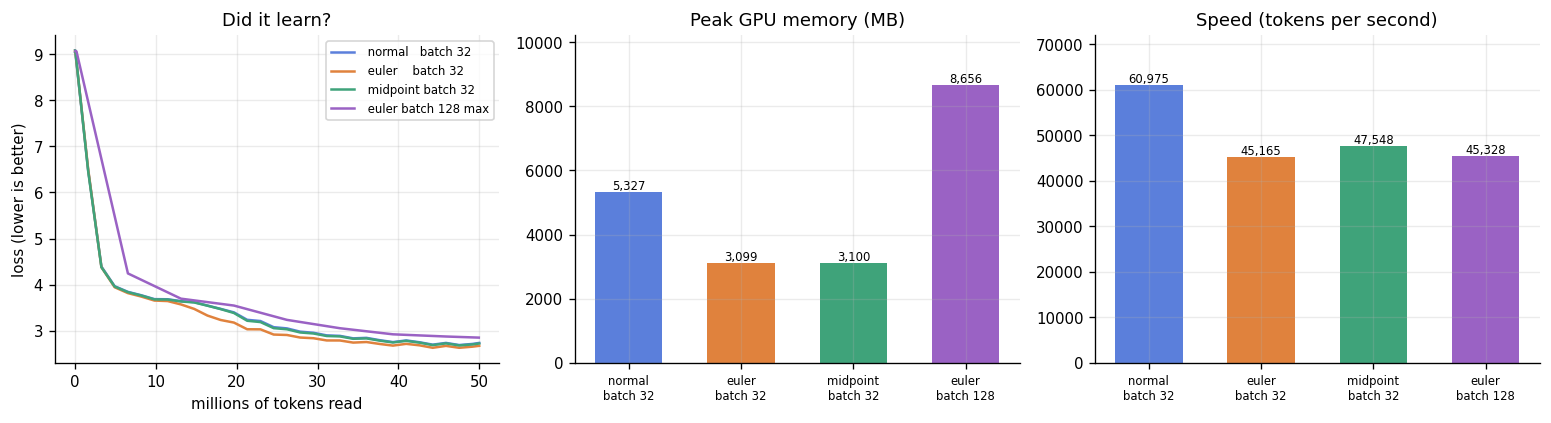

In [22]:
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.dpi": 120, "font.size": 9, "axes.grid": True, "grid.alpha": .25,
                     "axes.spines.top": False, "axes.spines.right": False})
COLOR = {"normal": "#5B7FDB", "euler": "#E0823D", "midpoint": "#3FA37A", "pushed": "#9A62C4"}

fig, ax = plt.subplots(1, 3, figsize=(13, 3.6))
for k in keys:
    h = results[k]["history"]
    ax[0].plot([d["tokens"]/1e6 for d in h], [d["loss"] for d in h],
               color=COLOR[k], lw=1.5, label=results[k]["label"][6:])
ax[0].set(xlabel="millions of tokens read", ylabel="loss (lower is better)", title="Did it learn?")
ax[0].legend(fontsize=7)

for a, (title, field) in zip(ax[1:], [("Peak GPU memory (MB)", "peak_memory_mb"),
                                      ("Speed (tokens per second)", "tokens_per_sec")]):
    vals = [results[k][field] for k in keys]
    a.bar(range(4), [v if v == v else 0 for v in vals], color=[COLOR[k] for k in keys], width=.6)
    a.set_xticks(range(4)); a.set_title(title); a.margins(y=.18)
    a.set_xticklabels([f"{results[k]['mode']}\nbatch {results[k]['batch']}" for k in keys], fontsize=7)
    for i, v in enumerate(vals):
        a.text(i, v if v == v else 0, f"{v:,.0f}" if v == v else "n/a",
               ha="center", va="bottom", fontsize=7)

fig.tight_layout(); fig.savefig("results.png", dpi=150); plt.show()

---

# Part 11 — What to write in your report

Copy the table from Part 10, then answer these in your own words.

**1. Which version won, Euler or midpoint?**
Give both validation losses and the gap. Then say whether you *believe* the gap. A difference of `0.05` is real; `0.002` is probably noise — you'd need a rerun with a different seed to tell.

**2. How much slower was reversibility?**
Compare against the lecture's 30–40%. The reason: every layer runs one extra time going down. A normal step costs about `1 forward + 2 backward = 3 units`, reversible about `4` — so you'd predict roughly **25–33%** slower.

**3. What happened when you pushed the batch to 128?**
The loss probably got *worse*. Explain why: the token budget is fixed at 50M, so batch 128 gives ~760 optimizer steps where batch 32 gave ~3,000. Reversibility buys you the *room* for a bigger batch; whether a bigger batch helps is a separate question, and at a fixed token budget it eventually stops helping. Saying this clearly is worth more than a good-looking number.

**4. How much memory was saved, and where did the rest go?**
Reversibility does **not** take activations to zero. Untouched: the weights, the optimiser's two running averages per weight, the token embedding, and the final `batch × 512 × 8192` grid of predictions. On a model this small that last one is close to 40% of the activation memory — which caps the saving at roughly 2×, not 10×. This is exactly the lecture's *"this is not one to one, some things are essentially going to be there."*

**5. The point most people miss.**
Reversibility is *exact* in real mathematics — Proof 1 showed ~`1e-16` in 64-bit. But we train in 16-bit for speed, and 16-bit is coarse: a tiny rounding error in a recovered hidden state gets magnified when it is fed back through the layer. Quote the round-trip error your runs printed.

**6. Cost.**
The US$ column is each run at your GPU's hourly rate. The interesting comparison isn't cost per run but **cost per unit of result** — reversibility costs more per token, but lets you do on one GPU what would otherwise need two.

---

### Worth trying afterwards

* Change `h` in `Config` and see how sensitive each version is to it.
* Run Proof 3 out to 64 layers. The normal model will run out of memory. The reversible ones won't.
* Turn dropout on inside `Block` and watch the gradients quietly go wrong — the restriction demonstrated rather than stated.
* Rerun runs 2 and 3 with a different seed to find out how big the Euler-vs-midpoint gap must be before it means anything.